# Assignment 1: Student Exam Pass Prediction

## Problem Statement

A training institute wants to predict whether a student will **pass or fail an exam** based on their preparation level.

You are given a dataset containing:

* Hours studied
* Previous test scores
* Attendance percentage

Using this data, build a **Logistic Regression model** that predicts whether a student will **Pass (1) or Fail (0)**.

Your task is to:

1. Load and explore the dataset
2. Perform data preprocessing if required
3. Split the dataset into training and testing sets
4. Train a Logistic Regression model
5. Evaluate the model using accuracy and confusion matrix
6. Predict whether a new student will pass or fail

---

## Dataset

Kaggle Dataset:
[https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression](https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression)

Important Columns:

| Feature         | Description                          |
| --------------- | ------------------------------------ |
| Hours Studied   | Number of hours student studied      |
| Previous Scores | Scores from previous tests           |
| Attendance      | Attendance percentage                |
| Pass/Fail       | Target variable (1 = Pass, 0 = Fail) |

Target Variable:

```
Pass/Fail
```



In [1]:
#Step 1: Import Libraries

import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
#Step 2: Load Dataset

import kagglehub

# Download latest version
path = kagglehub.dataset_download("nikhil7280/student-performance-multiple-linear-regression")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-performance-multiple-linear-regression' dataset.
Path to dataset files: /kaggle/input/student-performance-multiple-linear-regression


In [3]:
# Load the CSV into a DataFrame
files = os.listdir(path)
df = pd.read_csv(os.path.join(path, files[0]))
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [4]:
#Step 3: Define Features and Target

X = df[['Hours Studied','Previous Scores','Sleep Hours']]
#y = df['Performance Index']
y = (df['Performance Index'] >= 50).astype(int)

In [5]:
print(y.value_counts())
print("---------------")
print(y.value_counts(normalize=True) * 100)

Performance Index
1    5909
0    4091
Name: count, dtype: int64
---------------
Performance Index
1    59.09
0    40.91
Name: proportion, dtype: float64


In [ ]:
#Step 4: Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [ ]:
#Step 5: Scale Features

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#Step 6: Train Logistic Regression Model

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
#Step 7: Predictions

y_pred = model.predict(X_test)

In [ ]:
#Step 8: Evaluate Model

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)



Accuracy: 0.9705


In [ ]:
#Step 9: Evaluate Model - Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 798   28]
 [  31 1143]]


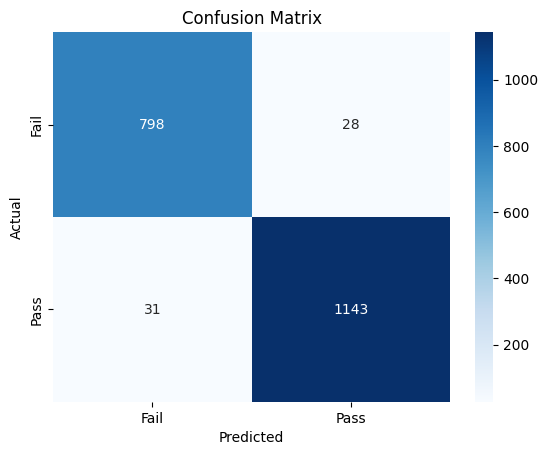

In [ ]:
#Step 10: Confusion Matrix Visualization

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail', 'Pass'],
            yticklabels=['Fail', 'Pass'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#Step 11: Predict New Student

new_student = [[7, 85, 7]]  # No column names, matches scaler format ✅
new_student_scaled = scaler.transform(new_student)
prediction = model.predict(new_student_scaled)

if prediction[0] == 1:
    print("Student will PASS ✅")
else:
    print("Student will FAIL ❌")

Student will PASS ✅
